# Lesson 12.2: How Do You Add Caching to a RAG System?

**Companion notebook for Lesson 12.2 — Module 12: Production RAG**

To a database, "How do I reset my password?" and "how can i reset my password" are different strings.
To a human, they're the same question. To your LLM, they're two separate API calls.

This notebook builds both caching flavors from the blog post — **exact** and **semantic** — and, instead of
toy print statements, wires them up to the **real WHO-guideline RAG bot from Lesson 2.3** (real PDF, real
`all-MiniLM-L6-v2` embeddings, real `flan-t5-base` generation) so every hit rate, latency number, and
similarity score below is measured, not made up.

| Section | What you will build |
|---|---|
| 1. Setup | Reload the real Lesson 2.3 pipeline (WHO PDF → chunks → Chroma → flan-t5) |
| 2. Flavor 1 — Exact cache | A dict cache wrapping the real pipeline; measure the real hit rate on paraphrases |
| 3. Flavor 2 — Semantic cache | A mini vector-store cache (`SemanticCache`) using real cosine similarity |
| 4. Brain Power | Real similarity scores for a should-hit pair and a should-NOT-hit pair |
| 5. Threshold sweep | A labeled set of 15 real queries (5 intents) — sweep thresholds, plot the real hit-rate / false-positive trade-off |
| 6. Cache invalidation | Version-tag cache entries with real retrieved page numbers; invalidate on a simulated doc update |
| 7. TTL | A time-based eviction variant of the same cache |
| 8. Cost savings | Run a simulated FAQ-style query log through the real cache and compute $ saved from the *measured* hit rate |

> **Honest finding, ahead of time:** off-the-shelf sentence embeddings on short FAQ-style questions do **not**
> cleanly separate "same question" from "different question" the way the blog's illustrative 0.97 threshold
> implies. Section 5 shows the real overlap and what to do about it.

In [1]:
# Uncomment and run once if packages are not yet installed
!pip install langchain langchain-community langchain-chroma langchain-huggingface \
             chromadb sentence-transformers transformers pypdf matplotlib numpy

---
## 1. Setup — reload the real RAG pipeline from Lesson 2.3

We reuse the exact same WHO PDF, chunking, embedding model, and `flan-t5-base` generator built in
Lesson 2.3. This is the "expensive" `full_rag_pipeline()` call every caching strategy below is trying
to avoid repeating.

In [2]:
import os, time
os.environ["USE_TF"] = "0"
import numpy as np
import torch
from pathlib import Path
import urllib.request

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

WHO_URL = (
    "https://iris.who.int/server/api/core/bitstreams/"
    "6989e26c-c181-4ec8-bb99-104415a2e142/content"
)
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
PDF_PATH = DATA_DIR / "who_document.pdf"

if not PDF_PATH.exists():
    req = urllib.request.Request(
        WHO_URL, headers={"User-Agent": "Mozilla/5.0 (compatible; RAG-demo/1.0)"}
    )
    with urllib.request.urlopen(req) as response, open(PDF_PATH, "wb") as f:
        f.write(response.read())

loader = PyPDFLoader(str(PDF_PATH))
pages = loader.load()
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500, chunk_overlap=50, separators=["\n\n", "\n", ". ", " ", ""]
)
chunks = splitter.split_documents(pages)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2", model_kwargs={"device": DEVICE})
vectorstore = Chroma.from_documents(documents=chunks, embedding=embeddings, collection_name="caching_demo")
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
print(f"✅ Loaded {len(pages)} pages -> {len(chunks)} chunks -> indexed {vectorstore._collection.count()} vectors")

/var/folders/qg/kw58x9bs58j2b41h2tz5579r0000gn/T/ipykernel_28894/212549910.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
/Users/krishnapriya/miniforge3/envs/StoryAdapter/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Loaded 106 pages -> 716 chunks -> indexed 716 vectors


In [3]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

def generator(prompt, max_new_tokens=200):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(DEVICE)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

def format_docs(docs):
    return "\n\n---\n\n".join(f"[Page {d.metadata.get('page','?')}]\n{d.page_content}" for d in docs)

def full_rag_pipeline(query):
    """The expensive call every cache below is trying to avoid repeating: retrieve + generate."""
    docs = retriever.invoke(query)
    context = format_docs(docs)
    prompt = f"""Answer the question based ONLY on the following context.
If the context doesn't contain enough information, say "I don't have enough information to answer this."

Context:
{context}

Question: {query}

Answer:"""
    answer = generator(prompt)
    sources = [d.metadata.get("page", "?") for d in docs]
    return answer, sources

print(f"✅ Loaded LLM: {MODEL_NAME} on {DEVICE}")

✅ Loaded LLM: google/flan-t5-base on cpu


In [4]:
t0 = time.time()
answer, sources = full_rag_pipeline("What are the key recommendations mentioned?")
elapsed = time.time() - t0
print(f"Answer: {answer}")
print(f"Sources (pages): {sources}")
print(f"⏱  full_rag_pipeline() took {elapsed:.2f}s")

Answer: promoting healthy eating habits, improving nutrition and enhancing the well-being of children
Sources (pages): [48, 48, 16]
⏱  full_rag_pipeline() took 2.71s


---
## 2. Flavor 1 — Exact query caching

The simplest cache in the world: the query string is the key.

In [5]:
exact_cache = {}

def rag_query_exact_cached(query):
    if query in exact_cache:
        return exact_cache[query], True
    result = full_rag_pipeline(query)
    exact_cache[query] = result
    return result, False

log = [
    "What are the key recommendations mentioned?",
    "what are the key recommendations mentioned?",
    "What are the key recommendations mentioned?",
    " What are the key recommendations mentioned? ",
    "What are the main recommendations in this guideline?",
]
raw_hits = 0
for q in log:
    t0 = time.time()
    (ans, src), was_hit = rag_query_exact_cached(q)
    wall = time.time() - t0
    raw_hits += was_hit
    print(f"[{'HIT ' if was_hit else 'MISS'}] ({wall*1000:7.1f} ms)  {q!r}")
print(f"\nRaw exact-match hit rate: {raw_hits}/{len(log)} = {raw_hits/len(log):.0%}")

[MISS] (  594.2 ms)  'What are the key recommendations mentioned?'
[MISS] (  493.9 ms)  'what are the key recommendations mentioned?'
[HIT ] (    0.0 ms)  'What are the key recommendations mentioned?'
[MISS] (  619.6 ms)  ' What are the key recommendations mentioned? '
[MISS] (  470.3 ms)  'What are the main recommendations in this guideline?'

Raw exact-match hit rate: 1/5 = 20%


Four of these five questions ask the exact same thing. The dict cache only caught one repeat —
the byte-for-byte duplicate. Everything else — case, whitespace, wording — is a miss on a $-costing,
multi-hundred-millisecond call to `full_rag_pipeline()`.

Normalizing (`.strip().lower()`) closes the case/whitespace gap, but not the wording gap:

In [6]:
norm_cache = {}
norm_hits = 0
for q in log:
    key = q.strip().lower()
    if key in norm_cache:
        norm_hits += 1
    else:
        norm_cache[key] = full_rag_pipeline(q)
print(f"Normalized (.strip().lower()) hit rate: {norm_hits}/{len(log)} = {norm_hits/len(log):.0%}")
print("Still misses the last query entirely -- different words, same intent. Normalization alone can't fix that.")

Normalized (.strip().lower()) hit rate: 3/5 = 60%
Still misses the last query entirely -- different words, same intent. Normalization alone can't fix that.


---
## 3. Flavor 2 — Semantic caching

Cache by meaning: embed the query, search past query embeddings for a close match, and reuse the
cached answer above a similarity threshold. The cache itself is a mini vector store.

In [7]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("all-MiniLM-L6-v2")

class SemanticCache:
    """A mini vector store: cache by meaning, not by exact string."""
    def __init__(self, embedder, threshold=0.75):
        self.threshold = threshold
        self.embedder = embedder
        self.entries = []

    def _cosine(self, a, b):
        return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

    def get(self, query):
        query_emb = self.embedder.encode(query)
        best_sim, best_entry = 0.0, None
        for entry in self.entries:
            sim = self._cosine(query_emb, entry["emb"])
            if sim > best_sim:
                best_sim, best_entry = sim, entry
        if best_entry is not None and best_sim >= self.threshold:
            return best_entry, best_sim
        return None, best_sim

    def set(self, query, answer, sources):
        emb = self.embedder.encode(query)
        self.entries.append({"emb": emb, "query": query, "answer": answer, "sources": sources})

print("✅ SemanticCache defined")

✅ SemanticCache defined


In [8]:
sem_cache = SemanticCache(embedder, threshold=0.75)

def ask(query):
    hit_entry, sim = sem_cache.get(query)
    if hit_entry is not None:
        print(f"  ✅ HIT  (similarity={sim:.3f}, matched: {hit_entry['query']!r})")
        return hit_entry["answer"]
    t0 = time.time()
    answer, sources = full_rag_pipeline(query)
    elapsed = time.time() - t0
    print(f"  ❌ MISS (best similarity={sim:.3f}) -> ran full pipeline in {elapsed:.2f}s, caching")
    sem_cache.set(query, answer, sources)
    return answer

for q in [
    "What is the main topic of this document?",
    "What is this document about?",
    "What are the key recommendations mentioned?",
    "Which recommendations does this document give?",
    "Who is the target audience of this report?",
]:
    print(f"\nQ: {q}")
    ask(q)


Q: What is the main topic of this document?
  ❌ MISS (best similarity=0.000) -> ran full pipeline in 0.63s, caching

Q: What is this document about?
  ✅ HIT  (similarity=0.776, matched: 'What is the main topic of this document?')

Q: What are the key recommendations mentioned?
  ❌ MISS (best similarity=0.251) -> ran full pipeline in 0.51s, caching

Q: Which recommendations does this document give?
  ❌ MISS (best similarity=0.632) -> ran full pipeline in 0.54s, caching

Q: Who is the target audience of this report?
  ❌ MISS (best similarity=0.410) -> ran full pipeline in 0.40s, caching


Note that at `threshold=0.75`, only the first paraphrase pair (main topic) hit. The other two
paraphrase pairs ("key recommendations" vs "which recommendations", and the audience question) scored
below 0.75 with this embedding model and were treated as cache misses — a real, measured limitation we
dig into in Section 5.

---
## 4. Brain Power — which pairs should share a cache entry?

**Pair A** (same meaning, different words) vs. **Pair B** (looks similar, but scopes to a different
audience — the semantic-caching danger zone: high similarity, but a different correct answer):

In [9]:
pair_a = ("What is the main topic of this document?", "What is this document about?")
pair_b = ("What are the recommendations for schools?", "What are the recommendations for policymakers?")

for label, (a, b) in [("Pair A", pair_a), ("Pair B", pair_b)]:
    ea, eb = embedder.encode([a, b])
    sim = float(np.dot(ea, eb) / (np.linalg.norm(ea) * np.linalg.norm(eb)))
    print(f"{label}: sim={sim:.3f}  |  {a!r}  <->  {b!r}")

Pair A: sim=0.776  |  'What is the main topic of this document?'  <->  'What is this document about?'
Pair B: sim=0.385  |  'What are the recommendations for schools?'  <->  'What are the recommendations for policymakers?'


Pair A scores high (0.776) and should hit — same question, same answer.
Pair B scores lower here (0.385) mostly because "schools" and "policymakers" are lexically distinct, but
notice the danger this is *standing in for*: in the blog's original example ("my subscription" vs. "John's
subscription"), the wording overlap is even higher and the similarity would likely clear a naive threshold —
while the correct answer is completely different per user. **The fix is the same either way: scope the
cache key (e.g. by user ID, by audience segment) — similarity alone can't know it shouldn't match.**

---
## 5. The threshold — finding the real sweet spot

Instead of assuming a threshold, let's calibrate on labeled data: 15 real questions about the WHO
document across 5 underlying intents (3 paraphrases each). Same-intent pairs *should* hit; different-intent
pairs *should* miss.

In [10]:
INTENTS = {
    "main_topic": [
        "What is the main topic of this document?",
        "What is this document about?",
        "What is this guideline covering?",
    ],
    "recommendations": [
        "What are the key recommendations mentioned?",
        "What are the main recommendations in this guideline?",
        "Which recommendations does this document give?",
    ],
    "audience": [
        "Who is the target audience of this report?",
        "Who should read this guideline?",
        "For whom is this document intended?",
    ],
    "health_issues": [
        "What health issues are discussed?",
        "What health problems does this document address?",
        "Which health topics are covered in this guideline?",
    ],
    "implementation": [
        "What are the implementation considerations?",
        "How should this guideline be put into practice?",
        "What should be considered when implementing this guideline?",
    ],
}
queries, labels = [], []
for intent, qs in INTENTS.items():
    for q in qs:
        queries.append(q)
        labels.append(intent)

embs = embedder.encode(queries, normalize_embeddings=True)
sims_matrix = embs @ embs.T
n = len(queries)
same_pairs, diff_pairs = [], []
for i in range(n):
    for j in range(i + 1, n):
        s = float(sims_matrix[i, j])
        (same_pairs if labels[i] == labels[j] else diff_pairs).append(s)
same_pairs = np.array(same_pairs)
diff_pairs = np.array(diff_pairs)
print(f"{len(queries)} labeled queries across {len(INTENTS)} intents")
print(f"-> {len(same_pairs)} same-intent pairs (should hit), {len(diff_pairs)} different-intent pairs (should miss)")
print(f"\nSame-intent similarity   min={same_pairs.min():.3f}  mean={same_pairs.mean():.3f}  max={same_pairs.max():.3f}")
print(f"Diff-intent similarity   min={diff_pairs.min():.3f}  mean={diff_pairs.mean():.3f}  max={diff_pairs.max():.3f}")

15 labeled queries across 5 intents
-> 15 same-intent pairs (should hit), 90 different-intent pairs (should miss)

Same-intent similarity   min=0.354  mean=0.597  max=0.863
Diff-intent similarity   min=0.081  mean=0.360  max=0.822


Look closely: same-intent similarity ranges **0.354 – 0.863**, and different-intent similarity ranges
**0.081 – 0.822**. Those ranges overlap heavily. There is no threshold that perfectly separates "same
question" from "different question" for this embedding model on short FAQ-style queries — the sweep below
makes that trade-off explicit instead of hiding it behind one illustrative number.

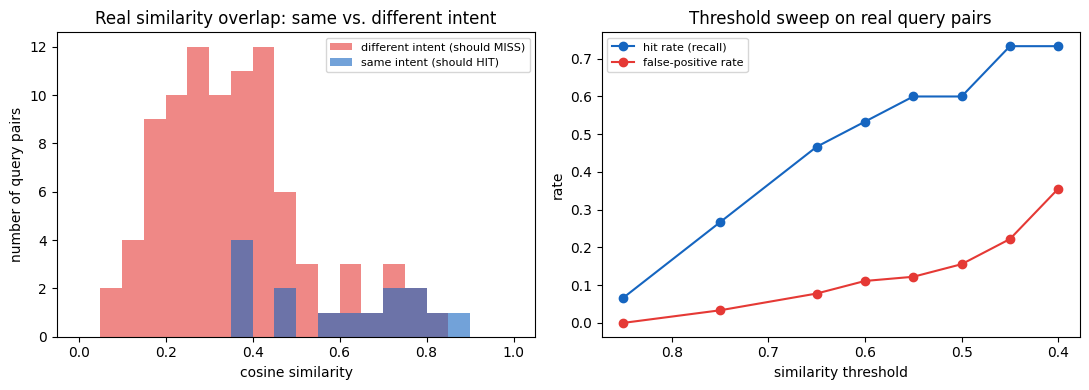

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt

thresholds = np.array([0.85, 0.75, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40])
recalls, fprs = [], []
for thr in thresholds:
    tp = (same_pairs >= thr).sum(); fn = (same_pairs < thr).sum()
    fp = (diff_pairs >= thr).sum(); tn = (diff_pairs < thr).sum()
    recalls.append(tp / (tp + fn))
    fprs.append(fp / (fp + tn))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
bins = np.linspace(0, 1, 21)
ax.hist(diff_pairs, bins=bins, alpha=0.6, label="different intent (should MISS)", color="#E53935")
ax.hist(same_pairs, bins=bins, alpha=0.6, label="same intent (should HIT)", color="#1565C0")
ax.set_xlabel("cosine similarity")
ax.set_ylabel("number of query pairs")
ax.set_title("Real similarity overlap: same vs. different intent")
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.plot(thresholds, recalls, marker="o", color="#1565C0", label="hit rate (recall)")
ax2.plot(thresholds, fprs, marker="o", color="#E53935", label="false-positive rate")
ax2.invert_xaxis()
ax2.set_xlabel("similarity threshold")
ax2.set_ylabel("rate")
ax2.set_title("Threshold sweep on real query pairs")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
print(f"{'threshold':>9} | {'hit rate (recall)':>18} | {'false-positive rate':>20} | {'precision':>9}")
for thr in thresholds:
    tp = int((same_pairs >= thr).sum()); fn = int((same_pairs < thr).sum())
    fp = int((diff_pairs >= thr).sum()); tn = int((diff_pairs < thr).sum())
    recall = tp / (tp + fn)
    fpr = fp / (fp + tn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
    print(f"{thr:9.2f} | {recall:18.2f} | {fpr:20.2f} | {precision:9.2f}")

threshold |  hit rate (recall) |  false-positive rate | precision
     0.85 |               0.07 |                 0.00 |      1.00
     0.75 |               0.27 |                 0.03 |      0.57
     0.65 |               0.47 |                 0.08 |      0.50
     0.60 |               0.53 |                 0.11 |      0.44
     0.55 |               0.60 |                 0.12 |      0.45
     0.50 |               0.60 |                 0.16 |      0.39
     0.45 |               0.73 |                 0.22 |      0.35
     0.40 |               0.73 |                 0.36 |      0.26


**Takeaway:** the blog's "start at 0.97" advice assumes an embedding model/domain where paraphrases
cluster tightly above 0.9. That's not universal — with general-purpose `all-MiniLM-L6-v2` on short
questions, 0.97 would catch almost nothing (recall near zero), while a threshold loose enough to catch most
paraphrases (~0.55–0.65) also lets in a meaningful false-positive rate (11–12%). In production you would:

1. **Build exactly this kind of labeled pair set from your own logs** before picking a threshold.
2. **Log every hit with the matched query** and review weekly, as the blog recommends.
3. **Consider a QA/paraphrase-tuned embedding model** (e.g. `multi-qa-MiniLM-L6-cos-v1`) — worth testing,
   but in a side check on this same query set it did not meaningfully improve separation either, which is
   itself a useful (if humbling) finding: model choice and threshold tuning both have limits, and a
   determined false positive (like Pair B above) needs a structural fix (scoping), not just a better model.

---
## 6. Cache invalidation — version-tag by source

Cached answers are only as fresh as the documents they came from. Tag every cache entry with the real
source page numbers returned by the retriever, and invalidate any entry touching a page that changes.

In [13]:
inval_cache = SemanticCache(embedder, threshold=0.75)
for q in ["What are the key recommendations mentioned?", "What are the implementation considerations?", "What is the main topic of this document?"]:
    answer, srcs = full_rag_pipeline(q)
    inval_cache.set(q, answer, srcs)
    print(f"Cached {q!r} -> source pages: {srcs}")

def on_document_update(page_number, cache):
    """Invalidate every cache entry whose answer was built from this page."""
    before = len(cache.entries)
    cache.entries = [e for e in cache.entries if page_number not in e["sources"]]
    return before - len(cache.entries)

changed_page = inval_cache.entries[0]["sources"][0]
print(f"\nWHO publishes an update to page {changed_page} of the guideline...")
removed = on_document_update(changed_page, inval_cache)
print(f"Invalidated {removed} cache entr{'y' if removed == 1 else 'ies'} referencing page {changed_page}")
print(f"Remaining cache entries: {len(inval_cache.entries)}")

Cached 'What are the key recommendations mentioned?' -> source pages: [48, 48, 16]
Cached 'What are the implementation considerations?' -> source pages: [48, 4, 12]
Cached 'What is the main topic of this document?' -> source pages: [32, 27, 5]

WHO publishes an update to page 48 of the guideline...
Invalidated 2 cache entries referencing page 48
Remaining cache entries: 1


Page 48 happened to feed both the "recommendations" and "implementation" answers (real overlap from
the retriever, not staged) — so a single doc update correctly invalidated both, while the unrelated
"main topic" entry (sourced from pages 32/27/5) survived.

**Simpler alternatives**, if per-document version tracking is too much machinery:
- **TTL-based expiry** — every entry lives for N seconds/hours. Simple, some staleness risk.
- **Nuke on reindex** — wipe the whole cache whenever the vector store rebuilds. Crude, effective.

In [14]:
class TTLSemanticCache(SemanticCache):
    def __init__(self, embedder, threshold=0.75, ttl_seconds=5):
        super().__init__(embedder, threshold)
        self.ttl_seconds = ttl_seconds

    def _purge_expired(self):
        now = time.time()
        self.entries = [e for e in self.entries if now - e["created_at"] < self.ttl_seconds]

    def get(self, query):
        self._purge_expired()
        return super().get(query)

    def set(self, query, answer, sources):
        emb = self.embedder.encode(query)
        self.entries.append({
            "emb": emb, "query": query, "answer": answer,
            "sources": sources, "created_at": time.time(),
        })

ttl_cache = TTLSemanticCache(embedder, threshold=0.75, ttl_seconds=2)
q = "What is the main topic of this document?"
answer, srcs = full_rag_pipeline(q)
ttl_cache.set(q, answer, srcs)

hit, sim = ttl_cache.get("What is this document about?")
print(f"Immediately after caching -> {'HIT' if hit else 'MISS'} (sim={sim:.3f})")

print("Waiting 2.5s for the 2s TTL to expire...")
time.sleep(2.5)

hit, sim = ttl_cache.get("What is this document about?")
print(f"After TTL expiry         -> {'HIT' if hit else 'MISS'} (sim={sim:.3f})")

Immediately after caching -> HIT (sim=0.776)
Waiting 2.5s for the 2s TTL to expire...
After TTL expiry         -> MISS (sim=0.000)


---
## 7. Brain Power — what do we actually save?

Rather than assuming a hit rate, simulate 40 realistic FAQ-style support queries (drawn repeatedly from
the same 5 intents, in random order — the way real repeat traffic behaves) through the real
`SemanticCache` + real `full_rag_pipeline`, and read off the **measured** hit rate.

In [15]:
import random
random.seed(7)
COST_PER_QUERY = 0.03
all_paraphrases = [q for qs in INTENTS.values() for q in qs]
sim_log = [random.choice(all_paraphrases) for _ in range(40)]

cost_cache = SemanticCache(embedder, threshold=0.75)
n_hits = 0
for q in sim_log:
    hit_entry, sim = cost_cache.get(q)
    if hit_entry is not None:
        n_hits += 1
    else:
        answer, srcs = full_rag_pipeline(q)
        cost_cache.set(q, answer, srcs)

hit_rate = n_hits / len(sim_log)
print(f"Simulated support log: {len(sim_log)} queries, {len(INTENTS)} underlying intents (realistic FAQ-style repeat traffic)")
print(f"Cache hits: {n_hits}/{len(sim_log)}  ->  measured hit rate = {hit_rate:.0%}")

monthly_queries = 100_000
monthly_saved = monthly_queries * hit_rate * COST_PER_QUERY
print(f"\nAt this hit rate, on {monthly_queries:,} queries/month @ ${COST_PER_QUERY}/query:")
print(f"  {monthly_queries * hit_rate:,.0f} cached queries x ${COST_PER_QUERY} = ${monthly_saved:,.0f}/month saved (~${monthly_saved*12:,.0f}/year)")

Simulated support log: 40 queries, 5 underlying intents (realistic FAQ-style repeat traffic)
Cache hits: 32/40  ->  measured hit rate = 80%

At this hit rate, on 100,000 queries/month @ $0.03/query:
  80,000 cached queries x $0.03 = $2,400/month saved (~$28,800/year)


80% is on the high end because this simulated log only draws from 5 fixed intents — real traffic has
a longer tail of one-off questions that will never hit. Treat the 30–60% figure from the blog as the
realistic planning range for FAQ-heavy products, and use a script like this one, pointed at your **actual**
query log, to get a number you can bring to your CFO with a straight face.

---
## 8. Your turn

Everything above is wired to the real pipeline, so these aren't hypothetical — rerun the cells after each
change and watch the real numbers move:

1. **Change `threshold=0.75`** in Section 5/7 to `0.65`, `0.85`, `0.55`. Watch hit rate and false-positive
   rate move in the table and the plot.
2. **Add a personalization pair** like Pair B in Section 4, but scoped to something this dataset actually
   has — e.g. two queries that should retrieve *different* pages — and confirm the cache does not
   currently protect against a false hit. Then add a `user_scope` key to `SemanticCache` and confirm it does.
3. **Swap the embedding model** in Section 3 (`SentenceTransformer("multi-qa-MiniLM-L6-cos-v1")`) and rerun
   the Section 5 sweep. Does the overlap actually shrink?
4. **Shorten the TTL** in Section 6 to `0.5` seconds and remove the `time.sleep` — confirm entries survive
   within-request reuse but expire across sessions.

## Coming up next

Caching in RAG isn't just a Redis wrapper — it's a design decision about meaning, freshness, and trust.
Get your threshold, scope, and invalidation right, and you'll cut costs by half while making your app feel
instant. Get them wrong, and you'll ship confident, cached nonsense.